In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
seed = 42
prefix_path = "../"

In [3]:
data = pd.read_csv(prefix_path + "data/salary_dataset.csv", index_col=0)

In [4]:
data.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [5]:
X, y = np.array(data["YearsExperience"]), np.array(data["Salary"])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=seed)

In [7]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((24,), (6,), (24,), (6,))

In [8]:
MAX_ITERATIONS = 1e6
TOLERANCE = 1e-2

In [9]:
def f(X: np.array, w: float, b: float) -> float:
    return w * X + b

In [10]:
def loss_function(X: np.array, y: np.array, w: float, b: float, metric: str) -> float:
    # Mean Squared Error (MSE)
    if metric.strip().lower() == "mse":
        return (1/(2 * X.shape[0])) * np.sum( (f(X, w, b) - y)**2 )

In [11]:
def update_coefficients(X: np.array, y: np.array, w: float, b: float, lr: float, metric: str, method: str) -> float:
    # Gradient Descent (GD)
    if method.strip().lower() == "gd":
        def d_loss_function(X: np.array, y: np.array, w: float, b: float, metric: str) -> float:
            # Derivatives of Mean Squared Error
            if metric.strip().lower() == "mse":
                dw = (1/X.shape[0]) * np.sum( (f(X, w, b) - y) * X )
                db = (1/X.shape[0]) * np.sum( f(X, w, b) - y )
                return dw, db
    
        dw, db = d_loss_function(X, y, w, b, metric)
        aux_w = w - lr * dw
        aux_b = b - lr * db
        return aux_w, aux_b

In [12]:
def gradient_descent(X: np.array, y: np.array, lr: float, metric: str):
    # Defining returnning structure
    hist_cost = list()
    hist_w_b = list()

    i = 1 # Iterations counter
    # Generating initial values for w and b
    w, b = 6, 7
    # Initial cost
    cost = loss_function(X, y, w, b, metric)
    hist_cost.append(cost)
    while (cost > TOLERANCE) and i < MAX_ITERATIONS:
        w, b = update_coefficients(X, y, w, b, lr, metric, method="gd")    # Update the coefficients of f
        cost = loss_function(X, y, w, b, metric)             # The total cost related to new coefficients
        # Saving the history
        hist_w_b.append((w, b))
        hist_cost.append(cost)
        i += 1
    
    return hist_w_b, hist_cost, i

In [13]:
def linear_regression(X: np.array, y: np.array, lr: float, metric: str, method: str) -> float:
    if method.strip().lower() == "gd":
        return gradient_descent(X, y, lr, metric)

In [14]:
inputs = {"X": X_train, "y": y_train, "lr": 0.01, "metric": "mse", "method": "gd"}
list_w_b, list_cost, total_iterations = linear_regression(**inputs)

In [15]:
len(list_cost), total_iterations

(1000000, 1000000)

In [16]:
def learning_curve(cost: list) -> None:
    x_len = len(cost)
    plt.plot(np.arange(x_len), cost)
    plt.xticks(ticks=np.arange(0, x_len, 1e5), rotation=45)

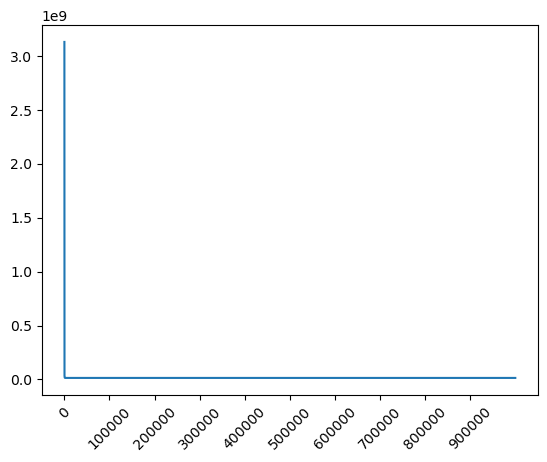

In [17]:
learning_curve(list_cost)

In [18]:
min(list_cost)

np.float64(13551124.865630664)

In [19]:
list_w_b[-10: -1]

[(np.float64(9423.815323031102), np.float64(24380.201479472868)),
 (np.float64(9423.815323031102), np.float64(24380.201479472868)),
 (np.float64(9423.815323031102), np.float64(24380.201479472868)),
 (np.float64(9423.815323031102), np.float64(24380.201479472868)),
 (np.float64(9423.815323031102), np.float64(24380.201479472868)),
 (np.float64(9423.815323031102), np.float64(24380.201479472868)),
 (np.float64(9423.815323031102), np.float64(24380.201479472868)),
 (np.float64(9423.815323031102), np.float64(24380.201479472868)),
 (np.float64(9423.815323031102), np.float64(24380.201479472868))]